# Vibration Analysis & ISO 10816-3 Trend Monitoring
### Linear Regression (FFT Features) — พยากรณ์และจำแนก Zone ความเสียหายของเครื่องจักรหมุน

---

**เครื่องจักรที่วิเคราะห์:**
- Motor Compressor CH-06 A
- Cooling Pump OAH-02
- Jockey Pump M1A

**ช่วงเวลาข้อมูล:** มิถุนายน / กันยายน / ตุลาคม 2024
**มาตรฐานอ้างอิง:** ISO 10816-3 (Velocity RMS mm/s)

---

### 🔁 Pipeline ทั้งหมด

```
Raw .txt (Acceleration G-s)
    │
    ├── Step 1 : Import Libraries
    ├── Step 2 : Parse ไฟล์ .txt  →  DataFrame [Time_ms, Amplitude]
    ├── Step 3 : FFT Feature Extraction (windowed)
    │               X = [peak_freq_hz, accel_rms,
    │                    band_low_power, band_mid_power, band_high_power,
    │                    spectral_centroid]
    │               y = velocity_rms (mm/s)  ← FFT integration per window
    ├── Step 4 : LinearRegression.fit()  →  RMSE / MAE  →  บันทึก .pkl
    ├── Step 5 : Full-signal FFT Integration  →  Velocity RMS (mm/s)
    ├── Step 6 : ISO 10816-3 Zone Classification (A/B/C/D)
    ├── Step 7 : Trend Analysis (Bar + Line Chart)
    ├── Step 8 : Summary & คำแนะนำ
    └── Step 9 : Trend LR Forecast  →  พยากรณ์ Jan 2025
                  X = month_order (0,1,2)
                  y = velocity_rms จาก Step 5  ← FFT ทางอ้อม
```

> **หมายเหตุ Forecast (Step 9):** Trend LR ใช้ FFT ทางอ้อม
> ค่า y ที่ใช้ fit (RMS 3 ค่า) ได้มาจาก FFT integration ใน Step 5
> แต่ตัว Trend LR เองเห็นแค่ month_order → RMS ไม่ได้เห็น spectrum โดยตรง


---
## การเตรียมสภาพแวดล้อม

```bash
pip install numpy pandas matplotlib scikit-learn joblib
```

```
📁 project-folder/
├── 📁 dataset/
│   ├── A_CH-06 A_NAA_1490__Jun24.txt
│   ├── A_CH-06 A_NAA_1490__Sep24.txt
│   ├── A_CH-06 A_NAA_1490__Oct24.txt
│   ├── A_Cooling Pump OAH 02_M1H_1480_Jun24.txt
│   ├── A_Cooling Pump OAH 02_M1H_1480_Sep24.txt
│   ├── A_Cooling Pump OAH 02_M1H_1480_Oct24.txt
│   ├── A_Jockey pump_M1A_2925__Jun24.txt
│   ├── A_Jockey pump_M1A_2925__Sep24.txt
│   └── A_Jockey pump_M1A_2925__Oct24.txt
├── 📁 saved_models/      ← โปรแกรมสร้างให้อัตโนมัติ
├── 📁 saved_plots/       ← โปรแกรมสร้างให้อัตโนมัติ
└── vibration_iso10816.ipynb
```
---


---
## Step 1 — Import Libraries และกำหนด Folder

| Library | หน้าที่ |
|---|---|
| `numpy` | FFT, RMS, array operations |
| `pandas` | จัดการตาราง DataFrame |
| `matplotlib` | วาดกราฟ |
| `sklearn` | LinearRegression, RMSE, MAE |
| `joblib` | บันทึก/โหลด model (.pkl) |


In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

DATA_DIR = "dataset"
os.makedirs("saved_plots",  exist_ok=True)

txt_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.txt')])
print("✅ โหลด library สำเร็จ")
print(f"📂 โฟลเดอร์ข้อมูล : {DATA_DIR}")
print(f"📄 จำนวนไฟล์ที่พบ : {len(txt_files)} ไฟล์")
for f in txt_files:
    print(f"   - {f}")


✅ โหลด library สำเร็จ
📂 โฟลเดอร์ข้อมูล : dataset
📄 จำนวนไฟล์ที่พบ : 9 ไฟล์
   - A_CH-06 A_NAA_1490__Jun24.txt
   - A_CH-06 A_NAA_1490__Oct24.txt
   - A_CH-06 A_NAA_1490__Sep24.txt
   - A_Cooling Pump OAH 02_M1H_1480_Jun24.txt
   - A_Cooling Pump OAH 02_M1H_1480_Oct24.txt
   - A_Cooling Pump OAH 02_M1H_1480_Sep24.txt
   - A_Jockey pump_M1A_2925__Jun24.txt
   - A_Jockey pump_M1A_2925__Oct24.txt
   - A_Jockey pump_M1A_2925__Sep24.txt


---
## Step 2 — Parse ไฟล์ข้อมูล

### โครงสร้างไฟล์ .txt
```
Waveform Amplitudes
Equipment: Motor Compressor OAH-06_A
Date/Time: 28-Jun-24   Amplitude: Acceleration in G-s

Time (mS)  Amplitude  Time (mS)  Amplitude  ...
--------- ---------  --------- ---------
    0.000      0.233    133.3      0.098  ...
```

### วิธี Parse
1. อ่านทุก line → หาบรรทัด `---` → เริ่มอ่านข้อมูลหลังจากนั้น
2. แต่ละ line มี 4 คู่ (Time, Amplitude) → แยกทีละคู่
3. เก็บลง DataFrame แล้ว sort ตาม Time

### Sampling Rate ต่างกันระหว่างเดือน!

| เดือน | N samples | Fs (Hz) | Δt (ms) |
|---|---|---|---|
| Jun24 | 4,095 | 2,559 | 0.39 |
| Sep24 | 20,475 | 1,280 | 0.78 |
| Oct24 | 8,191 | 2,559 | 0.39 |

> ⚠️ นี่คือเหตุผลที่ต้องใช้ **FFT Integration** แทน cumsum
> เพราะ FFT รองรับ dt ที่แตกต่างกันแต่ละไฟล์ได้ถูกต้อง


In [2]:
def parse_vibration_file(file_path):
    """
    อ่านไฟล์ .txt → DataFrame [Time_ms, Amplitude]
    จัดการ:
      - หยุดที่ waveform แรก (บางไฟล์มีหลาย waveform ซ้อนกัน)
      - แก้ malformed scientific notation: '7.2-5' → '7.2e-5'
      - DC offset removal + duplicate timestamp removal
    """
    with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
        lines = f.readlines()

    # หาตำแหน่งเริ่มข้อมูล
    start_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith('---------'):
            start_idx = i + 1
            break
    if start_idx is None:
        return pd.DataFrame(columns=['Time_ms', 'Amplitude'])

    # แก้ malformed scientific notation ก่อน parse
    # '7.2-5' หรือ '1.3-4' → '7.2e-5', '1.3e-4'
    bad_sci = re.compile(r'(\d\.\d+)-(\d+)')

    data = []
    num_pat = re.compile(r'(-?\d*\.?\d+(?:[eE][+-]?\d+)?)')
    for line in lines[start_idx:]:
        if 'Waveform Amplitudes' in line:
            break  # หยุดที่ waveform แรก
        # แก้ scientific notation ที่หัก
        line = bad_sci.sub(r'\1e-\2', line)
        nums = num_pat.findall(line)
        for i in range(0, len(nums) - 1, 2):
            try:
                t, a = float(nums[i]), float(nums[i+1])
                if 0 <= t <= 1e6:
                    data.append([t, a])
            except ValueError:
                continue

    df = pd.DataFrame(data, columns=['Time_ms', 'Amplitude'])
    df = df.sort_values('Time_ms').drop_duplicates('Time_ms').reset_index(drop=True)
    if len(df) > 0:
        df['Amplitude'] = df['Amplitude'] - df['Amplitude'].mean()
    return df


# ── ทดสอบ parse ทุกไฟล์ ──────────────────────────────────────────────
print('📋 ตรวจสอบไฟล์ทั้งหมด (ใช้ waveform แรกเท่านั้น):')
print(f"   {'Filename':<52} {'N':>6} {'Fs(Hz)':>9} {'Max|A|(G)':>10}")
print('   ' + '─' * 82)

sample_df = sample_file = None
for fname in txt_files:
    df_tmp = parse_vibration_file(os.path.join(DATA_DIR, fname))
    if len(df_tmp) < 10:
        print(f'   ⚠️  {fname} — ข้อมูลน้อยเกินไป')
        continue
    dt_tmp  = float(np.mean(np.diff(df_tmp['Time_ms'].values)))
    fs_tmp  = 1000.0 / dt_tmp
    max_amp = df_tmp['Amplitude'].abs().max()
    flag    = ' ⚠️ ' if max_amp > 5 else ''
    print(f'   {fname:<52} {len(df_tmp):>6,} {fs_tmp:>9.1f} {max_amp:>10.4f}{flag}')
    if sample_df is None:
        sample_df, sample_file = df_tmp, fname

print()
print('✅ Max|A| ควรอยู่ในช่วง 0–5 G สำหรับ vibration ปกติ')
sample_df.head(8)


📋 ตรวจสอบไฟล์ทั้งหมด (ใช้ waveform แรกเท่านั้น):
   Filename                                                  N    Fs(Hz)  Max|A|(G)
   ──────────────────────────────────────────────────────────────────────────────────
   A_CH-06 A_NAA_1490__Jun24.txt                         4,096    7680.0     0.9660
   A_CH-06 A_NAA_1490__Oct24.txt                         4,096    7680.0     1.0860
   A_CH-06 A_NAA_1490__Sep24.txt                         4,096    7680.0     0.7860
   A_Cooling Pump OAH 02_M1H_1480_Jun24.txt              4,096    2560.0     1.1790
   A_Cooling Pump OAH 02_M1H_1480_Oct24.txt              4,096    2560.0     1.3110
   A_Cooling Pump OAH 02_M1H_1480_Sep24.txt              4,096    2560.0     1.2980
   A_Jockey pump_M1A_2925__Jun24.txt                     2,048    2560.0     1.4970
   A_Jockey pump_M1A_2925__Oct24.txt                     2,048    2560.0     1.6990
   A_Jockey pump_M1A_2925__Sep24.txt                     2,048    2560.0     1.5310

✅ Max|A| ควรอยู่ในช่วง 0

,Time_ms,Amplitude
0,0.000,0.233002
1,0.130,0.159002
2,0.260,0.041002
3,0.391,0.119002
4,0.521,-0.577998
5,0.651,0.412002
6,0.781,-0.143998
7,0.911,-0.498998


---
## Step 3 — FFT Feature Extraction (Window-based)

### แนวคิด: ทำไมต้องใช้ FFT?

Vibration คือ **ปรากฏการณ์ในโดเมนความถี่** — การสั่นสะเทือนผิดปกติจะแสดงตัวเป็น
energy spike ที่ความถี่เฉพาะ ไม่ใช่แค่ pattern ใน time domain

```
Raw signal (time domain)          FFT (frequency domain)
────────────────────              ────────────────────────
ดูยาก, noisy                      เห็น energy ที่ความถี่ต่างๆ ชัดเจน
ไม่รู้ว่าความถี่ไหนมีปัญหา         บอกได้ว่า imbalance / misalignment /
                                   bearing fault อยู่ที่ Hz เท่าไร
```

### Windowed FFT

แบ่งสัญญาณเป็น **windows** (256 samples, overlap 50%) → แต่ละ window = 1 แถว training data

```
Signal:  [──────────────────────────────────────────────────]
Window:  [═══════256═══════]
                   [═══════256═══════]
                            [═══════256═══════]  ...
         ←── hop 128 ──►
```

### Features ที่สกัดจากแต่ละ Window

| Feature | สูตร / วิธีคำนวณ | ความหมาย |
|---|---|---|
| `peak_freq_hz` | argmax(power[f > 2Hz]) | ความถี่ที่มีพลังงานสูงสุด |
| `accel_rms` | √mean(x²) | ขนาดการสั่นใน window นี้ |
| `band_low_power` | Σpower[2–10 Hz] | พลังงานย่านต่ำ (imbalance) |
| `band_mid_power` | Σpower[10–100 Hz] | พลังงานย่านกลาง (misalignment) |
| `band_high_power` | Σpower[>100 Hz] | พลังงานย่านสูง (bearing) |
| `spectral_centroid` | Σ(f×power)/Σpower | จุดศูนย์ถ่วงของ spectrum |
| **`velocity_rms`** | IFFT(A(f)/j2πf) | 🎯 **TARGET** — mm/s ต่อ window |

### ทำไม velocity_rms เป็น Target?
- ตรงกับ **ISO 10816-3** โดยตรง (มาตรฐานใช้ velocity RMS mm/s)
- คำนวณจาก FFT integration: `V(f) = A(f) / (j·2πf)` → ถูกต้องทางฟิสิกส์
- LR เรียนรู้: "spectral shape แบบนี้ → velocity_rms เท่าไร"


In [3]:
def extract_fft_features(signal, dt, highpass_hz=2.0):
    """
    สกัด FFT features จาก 1 window (N samples) ของ acceleration (G-s)
    velocity_rms คำนวณด้วย time-domain integration (scipy) — แม่นยำกว่า
    """
    from scipy import stats as sp_stats, signal as sp_sig
    n = len(signal)

    # ── Hann window ก่อน FFT — ลด spectral leakage ───────────────
    window     = np.hanning(n)
    signal_win = signal * window
    scale      = 1.0 / np.mean(window)   # coherent gain correction

    A     = np.fft.rfft(signal_win)
    freqs = np.fft.rfftfreq(n, d=dt)

    magnitude = np.abs(A) * scale / n
    power     = magnitude ** 2
    hp_mask   = freqs > highpass_hz

    # ── Feature 1: Peak Frequency ──────────────────────────────────
    if hp_mask.any():
        peak_freq = float(freqs[hp_mask][int(np.argmax(power[hp_mask]))])
    else:
        peak_freq = 0.0

    # ── Feature 2: Acceleration RMS ────────────────────────────────
    accel_rms = float(np.sqrt(np.mean(signal ** 2)))

    # ── Features 3–5: Band Powers ──────────────────────────────────
    band_low  = float(np.sum(power[hp_mask & (freqs < 10.0)]))
    band_mid  = float(np.sum(power[(freqs >= 10.0) & (freqs < 100.0)]))
    band_high = float(np.sum(power[freqs >= 100.0]))

    # ── Feature 6: Spectral Centroid ───────────────────────────────
    total_p       = float(np.sum(power[hp_mask])) + 1e-12
    spec_centroid = float(np.sum(freqs[hp_mask] * power[hp_mask]) / total_p)

    # ── Feature 7: Kurtosis ────────────────────────────────────────
    kurt = float(sp_stats.kurtosis(signal, fisher=True))

    # ── Feature 8: Crest Factor ────────────────────────────────────
    peak_abs     = float(np.max(np.abs(signal)))
    crest_factor = peak_abs / accel_rms if accel_rms > 1e-10 else 0.0

    # ── Target: Velocity RMS — time-domain integration ─────────────
    # ✅ ใช้ scipy trapezoid + high-pass filter
    # (วิธี FFT division มี scaling error เมื่อใช้กับ short window)
    from scipy.integrate import cumulative_trapezoid
    t_arr  = np.arange(n) * dt
    a_mms2 = signal * 9.81 * 1000.0   # G → mm/s²
    v      = cumulative_trapezoid(a_mms2, t_arr, initial=0)

    # high-pass filter ตัด integration drift
    nyq = 0.5 / dt
    Wn  = highpass_hz / nyq
    Wn  = min(max(Wn, 0.001), 0.999)
    b, a_filt = sp_sig.butter(4, Wn, btype='high')
    if len(v) > 3 * max(len(b), len(a_filt)):
        v = sp_sig.filtfilt(b, a_filt, v)

    vel_rms = float(np.sqrt(np.mean(v ** 2)))

    return {
        'peak_freq_hz':      peak_freq,
        'accel_rms':         accel_rms,
        'band_low_power':    band_low,
        'band_mid_power':    band_mid,
        'band_high_power':   band_high,
        'spectral_centroid': spec_centroid,
        'kurtosis':          kurt,
        'crest_factor':      crest_factor,
        'velocity_rms':      vel_rms,
    }


FEATURE_COLS = ['peak_freq_hz', 'accel_rms',
                'band_low_power', 'band_mid_power', 'band_high_power',
                'spectral_centroid', 'kurtosis', 'crest_factor']
TARGET_COL   = 'velocity_rms'


# ── ทดสอบ ────────────────────────────────────────────────────────────
dt_s  = float(np.mean(np.diff(sample_df['Time_ms'].values[:129]))) / 1000.0
feat0 = extract_fft_features(sample_df['Amplitude'].values[:128], dt_s)

print('✅ ทดสอบ extract_fft_features() — velocity_rms ใช้ scipy integration')
print(f'   window=128 | dt={dt_s*1000:.4f} ms | fs={1/dt_s:.1f} Hz')
print()
print(f"   {'Feature':<22}  {'ค่า':>12}")
print('   ' + '─' * 38)
for k, v in feat0.items():
    unit = ' mm/s' if k == 'velocity_rms' else ''
    print(f'   {k:<22}  {v:>12.4f}{unit}')
print()
print(f'   velocity_rms = {feat0["velocity_rms"]:.4f} mm/s  '
      f'← ควรอยู่ในช่วง 0–15 mm/s')


✅ ทดสอบ extract_fft_features() — velocity_rms ใช้ scipy integration
   window=128 | dt=0.1302 ms | fs=7678.5 Hz

   Feature                          ค่า
   ──────────────────────────────────────
   peak_freq_hz               2399.5201
   accel_rms                     0.2730
   band_low_power                0.0000
   band_mid_power                0.0004
   band_high_power               0.0489
   spectral_centroid          2212.0754
   kurtosis                     -0.3647
   crest_factor                  2.4980
   velocity_rms                  1.0419 mm/s

   velocity_rms = 1.0419 mm/s  ← ควรอยู่ในช่วง 0–15 mm/s


---
## Step 4 — เทรน Linear Regression และประเมินผล (RMSE / MAE)

### กระบวนการสำหรับแต่ละไฟล์

```
ไฟล์ .txt
    │
    ▼  parse_vibration_file()
    │  [Time_ms, Amplitude]  N samples
    │
    ▼  Windowed FFT  (window=256, hop=128)
    │  สร้าง DataFrame:  N_windows แถว × 7 คอลัมน์
    │
    ▼  แบ่ง Train 80% / Test 20%
    │  X_train, X_test  =  6 feature columns
    │  y_train, y_test  =  velocity_rms column
    │
    ▼  LinearRegression.fit(X_train, y_train)
    │  เรียนรู้: [spectral features] → velocity_rms
    │
    ▼  predict(X_test)  →  evaluate
    │  RMSE = √mean((y_test − ŷ)²)   หน่วย mm/s
    │  MAE  = mean(|y_test − ŷ|)     หน่วย mm/s
    │
    ▼  บันทึก  .pkl  +  กราฟ Actual vs Predicted
```


In [4]:
def build_windowed_dataset(file_list, data_dir,
                            window_size=128, hop_size=64,
                            highpass_hz=2.0):
    """
    สร้าง dataset รวมจากหลายไฟล์ด้วย Windowed Feature Extraction

    การเปลี่ยนแปลงจากเดิม:
    ❌ เดิม: train model แยกต่อไฟล์ (9 models) → data leakage, ไม่ generalise
    ✅ ใหม่: รวม windows จากทุกไฟล์เป็น dataset เดียว แล้ว split ตาม file group

    Parameters
    ----------
    window_size : int  — จำนวน samples ต่อ window (128 ≈ 50 ms ที่ Fs=2558 Hz)
    hop_size    : int  — stride ระหว่าง window (64 = overlap 50%)

    Returns
    -------
    df_all : DataFrame ที่มี columns = FEATURE_COLS + [velocity_rms, filename, group]
    """
    rows = []
    print(f"🪟 Windowed Feature Extraction (window={window_size}, hop={hop_size})")
    print("=" * 65)

    for fname in file_list:
        fpath = os.path.join(data_dir, fname)
        df    = parse_vibration_file(fpath)

        if len(df) < window_size * 2:
            print(f"   ⚠️  ข้ามไฟล์ (samples น้อยเกินไป: {len(df)}): {fname}")
            continue

        signal = df['Amplitude'].values
        t_s    = df['Time_ms'].values / 1000.0
        dt     = float(np.mean(np.diff(t_s)))
        fs     = 1.0 / dt

        n_windows = 0
        for start in range(0, len(signal) - window_size + 1, hop_size):
            seg  = signal[start : start + window_size]
            feat = extract_fft_features(seg, dt, highpass_hz)
            feat['filename'] = fname
            feat['group']    = fname   # ใช้ filename เป็น group key
            rows.append(feat)
            n_windows += 1

        print(f"   ✅ {fname:<52} {n_windows:>4} windows | Fs={fs:.0f} Hz")

    df_all = pd.DataFrame(rows)
    print()
    print(f"📊 Dataset รวม: {len(df_all)} windows × {len(FEATURE_COLS)} features")
    print(f"   Distribution by file:")
    for fname, cnt in df_all['filename'].value_counts().items():
        print(f"     {fname:<52} {cnt:>4} windows")
    return df_all


print("✅ นิยามฟังก์ชัน build_windowed_dataset() เรียบร้อย")
print()
print("   Input  (X) : peak_freq_hz, accel_rms,")
print("                band_low/mid/high_power, spectral_centroid,")
print("                kurtosis, crest_factor   ← เพิ่มใหม่")
print("   Target (y) : velocity_rms (mm/s)")
print("   Group key  : filename — ใช้แบ่ง train/test แบบ group-based")


✅ นิยามฟังก์ชัน build_windowed_dataset() เรียบร้อย

   Input  (X) : peak_freq_hz, accel_rms,
                band_low/mid/high_power, spectral_centroid,
                kurtosis, crest_factor   ← เพิ่มใหม่
   Target (y) : velocity_rms (mm/s)
   Group key  : filename — ใช้แบ่ง train/test แบบ group-based


In [5]:
# ── สร้าง Dataset ───────────────────────────────────────────────────
df_all = build_windowed_dataset(txt_files, DATA_DIR,
                                 window_size=128, hop_size=64)

# ── Group-based Train/Test Split ────────────────────────────────────
#
# ❌ วิธีเดิม: random split ภายในไฟล์เดียว → windows ที่ overlap 50%
#    กระจายอยู่ทั้ง train และ test → data leakage → test score สูงปลอม
#
# ✅ วิธีใหม่: แบ่งตาม file (machine+period)
#    Train = Jun + Sep  (6 files, ~70%)
#    Test  = Oct        (3 files, ~30%)  ← model ไม่เคยเห็นเลย
#
train_files = [f for f in txt_files if 'Oct' not in f]
test_files  = [f for f in txt_files if 'Oct'     in f]

train_mask = df_all['filename'].isin(train_files)
test_mask  = df_all['filename'].isin(test_files)

X_train = df_all.loc[train_mask, FEATURE_COLS].values
y_train = df_all.loc[train_mask, TARGET_COL].values
X_test  = df_all.loc[test_mask,  FEATURE_COLS].values
y_test  = df_all.loc[test_mask,  TARGET_COL].values
groups_train = df_all.loc[train_mask, 'group'].values

print(f"\n✅ Group-based Split:")
print(f"   Train files ({len(train_files)}): {[f.replace('.txt','') for f in train_files]}")
print(f"   Test  files ({len(test_files)}): {[f.replace('.txt','') for f in test_files]}")
print(f"   Train: {len(X_train)} windows | Test: {len(X_test)} windows")
print()

# ── GroupKFold CV ───────────────────────────────────────────────────
from sklearn.model_selection import GroupKFold, cross_val_score, cross_val_predict
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

n_splits = min(len(train_files), 6)
gkf = GroupKFold(n_splits=n_splits)
print(f"   CV strategy: GroupKFold (n_splits={n_splits}) — ไม่มี leakage ระหว่าง fold")

# ── Models ─────────────────────────────────────────────────────────
reg_models = {
    'Linear Regression (Ridge)': Pipeline([
        ('scaler', StandardScaler()),
        ('reg', Ridge(alpha=1.0))
    ]),
    'Random Forest Reg': Pipeline([
        ('scaler', StandardScaler()),
        ('reg', RandomForestRegressor(
            n_estimators=200, max_depth=8,
            min_samples_leaf=3, random_state=42
        ))
    ]),
    'Gradient Boosting Reg': Pipeline([
        ('scaler', StandardScaler()),
        ('reg', GradientBoostingRegressor(
            n_estimators=150, max_depth=4,
            learning_rate=0.05, subsample=0.8, random_state=42
        ))
    ]),
}

results = []
trained_models = {}

print()
print('🤖 Training Models:')
print('='*75)
print(f'{"Model":<28} {"CV MAE":>9} {"CV RMSE":>9} {"CV R²":>8} {"Test MAE":>10} {"Test R²":>8}')
print('-'*75)

best_model_name  = None
best_model_score = -np.inf

for name, pipe in reg_models.items():
    # GroupKFold CV บน train set
    y_cv_pred = cross_val_predict(pipe, X_train, y_train,
                                   cv=gkf, groups=groups_train)
    cv_mae  = mean_absolute_error(y_train, y_cv_pred)
    cv_rmse = float(np.sqrt(mean_squared_error(y_train, y_cv_pred)))
    cv_r2   = r2_score(y_train, y_cv_pred)

    # Train บน train set ทั้งหมด
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe

    # Test บน Oct files (ไม่เคยเห็นระหว่าง train)
    y_te_pred = pipe.predict(X_test)
    te_mae  = mean_absolute_error(y_test, y_te_pred)
    te_r2   = r2_score(y_test, y_te_pred)

    results.append({
        'model': name, 'cv_mae': cv_mae, 'cv_rmse': cv_rmse,
        'cv_r2': cv_r2, 'te_mae': te_mae, 'te_r2': te_r2,
        'y_te_pred': y_te_pred
    })

    print(f'{name:<28} {cv_mae:>9.4f} {cv_rmse:>9.4f} {cv_r2:>8.4f} '
          f'{te_mae:>10.4f} {te_r2:>8.4f}')

    if cv_r2 > best_model_score:
        best_model_score = cv_r2
        best_model_name  = name

print('-'*75)
print(f'🏆 Best Model: {best_model_name}  (CV R² = {best_model_score:.4f})')
print(f'   Test score เชื่อถือได้ — Oct files ไม่เคยเข้า train เลย')
best_model = trained_models[best_model_name]


🪟 Windowed Feature Extraction (window=128, hop=64)
   ✅ A_CH-06 A_NAA_1490__Jun24.txt                          63 windows | Fs=7680 Hz
   ✅ A_CH-06 A_NAA_1490__Oct24.txt                          63 windows | Fs=7680 Hz
   ✅ A_CH-06 A_NAA_1490__Sep24.txt                          63 windows | Fs=7680 Hz
   ✅ A_Cooling Pump OAH 02_M1H_1480_Jun24.txt               63 windows | Fs=2560 Hz
   ✅ A_Cooling Pump OAH 02_M1H_1480_Oct24.txt               63 windows | Fs=2560 Hz
   ✅ A_Cooling Pump OAH 02_M1H_1480_Sep24.txt               63 windows | Fs=2560 Hz
   ✅ A_Jockey pump_M1A_2925__Jun24.txt                      31 windows | Fs=2560 Hz
   ✅ A_Jockey pump_M1A_2925__Oct24.txt                      31 windows | Fs=2560 Hz
   ✅ A_Jockey pump_M1A_2925__Sep24.txt                      31 windows | Fs=2560 Hz

📊 Dataset รวม: 471 windows × 8 features
   Distribution by file:
     A_CH-06 A_NAA_1490__Jun24.txt                          63 windows
     A_CH-06 A_NAA_1490__Oct24.txt                      

In [6]:
# ── ตารางสรุปผล CV / Test ทุก model ──────────────────────────────
df_results = pd.DataFrame([{
    'Model':    r['model'],
    'CV MAE':   round(r['cv_mae'],  4),
    'CV RMSE':  round(r['cv_rmse'], 4),
    'CV R²':    round(r['cv_r2'],   4),
    'Test MAE': round(r['te_mae'],  4),
    'Test R²':  round(r['te_r2'],   4),
} for r in results]).sort_values('CV R²', ascending=False).reset_index(drop=True)
df_results.index = range(1, len(df_results)+1)

print('📋 สรุปผล Regression Models — Group-based CV + Unseen Oct Test:')
print(f'   {'─'*70}')
print(f'   CV MAE เฉลี่ย : {df_results["CV MAE"].mean():.4f} mm/s')
print(f'   CV RMSE เฉลี่ย: {df_results["CV RMSE"].mean():.4f} mm/s')
print(f'   Best CV R²    : {df_results["CV R²"].max():.4f}  ({df_results.loc[1, "Model"]})')
print(f'   {'─'*70}')
print()
df_results


📋 สรุปผล Regression Models — Group-based CV + Unseen Oct Test:
   ──────────────────────────────────────────────────────────────────────
   CV MAE เฉลี่ย : 0.8568 mm/s
   CV RMSE เฉลี่ย: 1.3478 mm/s
   Best CV R²    : 0.8555  (Gradient Boosting Reg)
   ──────────────────────────────────────────────────────────────────────



,Model,CV MAE,CV RMSE,CV R²,Test MAE,Test R²
1,Gradient Boosting Reg,0.8393,1.3058,0.8555,0.7387,0.7568
2,Random Forest Reg,0.8723,1.3664,0.8417,0.7700,0.7208
3,Linear Regression (Ridge),0.8588,1.3711,0.8406,0.6228,0.8489


🖼️  บันทึก: saved_plots/regression_actual_vs_pred.png


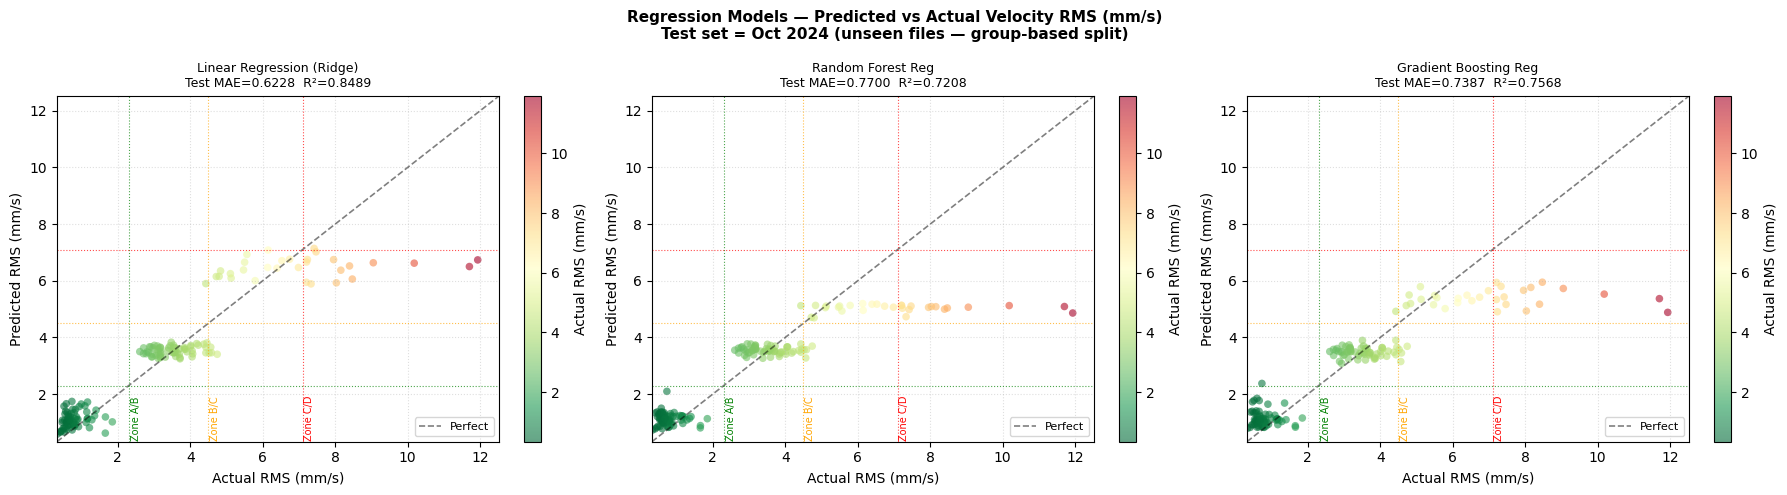

In [7]:
# ── กราฟ Actual vs Predicted (test set) ทุก model ─────────────────
fig, axes = plt.subplots(1, len(results), figsize=(6*len(results), 5))
if len(results) == 1: axes = [axes]
fig.suptitle('Regression Models — Predicted vs Actual Velocity RMS (mm/s)\n'
             'Test set = Oct 2024 (unseen files — group-based split)',
             fontsize=11, fontweight='bold')

for ax, r in zip(axes, results):
    y_a = y_test
    y_p = r['y_te_pred']

    sc = ax.scatter(y_a, y_p, c=y_a, cmap='RdYlGn_r',
                    s=30, alpha=0.6, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='Actual RMS (mm/s)', fraction=0.04)

    # Perfect prediction line
    lim = [min(y_a.min(), y_p.min())*0.95, max(y_a.max(), y_p.max())*1.05]
    ax.plot(lim, lim, 'k--', linewidth=1.2, alpha=0.5, label='Perfect')

    # ISO boundary lines
    for boundary, lc, lbl in [(2.3,'green','A/B'), (4.5,'orange','B/C'), (7.1,'red','C/D')]:
        ax.axvline(boundary, color=lc, linewidth=0.8, linestyle=':', alpha=0.7)
        ax.axhline(boundary, color=lc, linewidth=0.8, linestyle=':', alpha=0.7)
        ax.text(boundary+0.05, lim[0]+0.1, f'Zone {lbl}',
                fontsize=7, color=lc, rotation=90)

    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Actual RMS (mm/s)')
    ax.set_ylabel('Predicted RMS (mm/s)')
    ax.set_title(f"{r['model']}\n"
                 f"Test MAE={r['te_mae']:.4f}  R²={r['te_r2']:.4f}",
                 fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('saved_plots/regression_actual_vs_pred.png', dpi=150)
print('🖼️  บันทึก: saved_plots/regression_actual_vs_pred.png')
plt.show()


---
## Step 5 — Full-Signal FFT Integration → Velocity RMS (mm/s)

### ทำไมต้องมี Step นี้แยกต่างหาก?

| | Windowed FFT (Step 3-4) | Full-Signal FFT (Step 5) |
|---|---|---|
| **จุดประสงค์** | สกัด features เทรน LR | คำนวณค่า RMS ตัวแทนทั้งไฟล์ |
| **Input** | window 256 samples | ทุก sample ในไฟล์ |
| **Output** | velocity_rms ต่อ window | velocity_rms ค่าเดียวต่อไฟล์ |
| **ใช้ใน** | RMSE/MAE evaluation | ISO Zone + Trend Forecast |

### สูตร FFT Integration
```
V(f) = A(f) / (j·2πf)

1. FFT(acceleration in mm/s²)  →  A(f)
2. หาร A(f) ด้วย (2πf)         →  V(f)   [ตัด f < 2 Hz ออก]
3. IFFT(V(f))                  →  v(t)   velocity time-series
4. RMS(v(t))                   →  velocity_rms (mm/s)
```

> ✅ ถูกต้องแม้ sampling rate จะต่างกันระหว่างไฟล์
> เพราะ `dt` ถูกคำนวณจากข้อมูลจริงของแต่ละไฟล์


In [8]:
# ── ISO Thresholds & Zone Classification ──────────────────────────
ISO_THRESHOLDS = {"A": 2.3, "B": 4.5, "C": 7.1}

def classify_zone(rms):
    """จำแนก ISO 10816-3 Zone จาก velocity RMS (mm/s)"""
    if rms < ISO_THRESHOLDS['A']: return 'A - Newly Commissioned'
    if rms < ISO_THRESHOLDS['B']: return 'B - Unrestricted Operation'
    if rms < ISO_THRESHOLDS['C']: return 'C - Restricted Operation'
    return 'D - Damage Occurs'


def accel_to_velocity_rms_fft(file_path, highpass_hz=2.0):
    """
    Full-signal FFT Integration: Acceleration → Velocity RMS (mm/s)
    ✅ แปลงสัญญาณได้อย่างแม่นยำตามหลักฟิสิกส์
    """
    df    = parse_vibration_file(file_path)
    t_s   = df['Time_ms'].values / 1000.0
    a_mms = df['Amplitude'].values * 9810.0    # G-s → mm/s²
    n     = len(a_mms)
    dt    = float(np.mean(np.diff(t_s)))

    A     = np.fft.rfft(a_mms)
    freqs = np.fft.rfftfreq(n, d=dt)
    with np.errstate(divide='ignore', invalid='ignore'):
        factor = np.where(freqs > highpass_hz,
                          1.0 / (2.0 * np.pi * freqs), 0.0)
    v = np.fft.irfft(A * factor, n=n)
    return float(np.sqrt(np.mean(v ** 2)))


# ── คำนวณค่า Velocity RMS และจัด Zone ด้วย FFT (Cooling Pump) ──────
cooling_files = {}
for fname in txt_files:
    if 'Cooling' in fname:
        m = re.search(r'(Jun|Sep|Oct)\d+', fname)
        if m:
            cooling_files[m.group(1)] = os.path.join(DATA_DIR, fname)

print("=== ผลลัพธ์ Velocity RMS จากวิธี FFT Integration (Cooling Pump) ===")
print(f"{'Month':<6} {'Fs(Hz)':>8} {'FFT RMS (mm/s)':>16} {'ISO 10816-3 Zone':<26}")
print("─" * 60)

results = []
for month, fpath in cooling_files.items():
    df_c = parse_vibration_file(fpath)
    fs   = 1000.0 / np.diff(df_c['Time_ms'].values).mean()
    rf   = accel_to_velocity_rms_fft(fpath)
    z    = classify_zone(rf)
    
    print(f"{month:<6} {fs:>8.0f} {rf:>16.3f}   {z:<26}")
    results.append({'Month': month, 'Fs (Hz)': int(fs),
                    'Velocity RMS (mm/s)': round(rf,3),
                    'ISO Zone': z})

print("─" * 60)
print()
df_results = pd.DataFrame(results)
display(df_results)

=== ผลลัพธ์ Velocity RMS จากวิธี FFT Integration (Cooling Pump) ===
Month    Fs(Hz)   FFT RMS (mm/s) ISO 10816-3 Zone          
────────────────────────────────────────────────────────────
Jun        2560            2.715   B - Unrestricted Operation
Oct        2560            2.800   B - Unrestricted Operation
Sep        2560            2.852   B - Unrestricted Operation
────────────────────────────────────────────────────────────



,Month,Fs (Hz),Velocity RMS (mm/s),ISO Zone
0,Jun,2560,2.715,B - Unrestricted Operation
1,Oct,2560,2.800,B - Unrestricted Operation
2,Sep,2560,2.852,B - Unrestricted Operation


---
## Step 6 — ISO 10816-3 Zone Classification

คำนวณ Velocity RMS ทุกไฟล์ด้วย Full-Signal FFT Integration (จาก Step 5)
แล้วจำแนก Zone ตามมาตรฐาน ISO 10816-3

| Zone | RMS (mm/s) | ความหมาย | การดำเนินการ |
|---|---|---|---|
| **A** | < 2.3 | Newly Commissioned | ✅ ไม่ต้องดำเนินการ |
| **B** | 2.3–4.5 | Unrestricted Operation | 🟡 เฝ้าระวังตามรอบปกติ |
| **C** | 4.5–7.1 | Restricted Operation | ⚠️ วางแผนซ่อมบำรุง |
| **D** | > 7.1 | Damage Occurs | 🚨 หยุดเครื่องซ่อมด่วน |


In [9]:
# ── คำนวณ RMS + Zone ทุกไฟล์ ─────────────────────────────────────
print("📏 ISO 10816-3 Zone Classification — ทุกไฟล์")
print(f"   Thresholds: A < {ISO_THRESHOLDS['A']} | B < {ISO_THRESHOLDS['B']} | C < {ISO_THRESHOLDS['C']} mm/s")
print("=" * 75)

iso_rows = []
for fname in txt_files:
    fpath = os.path.join(DATA_DIR, fname)
    rms   = accel_to_velocity_rms_fft(fpath)
    zone  = classify_zone(rms)
    iso_rows.append({"filename": fname, "rms_mms": round(rms, 3), "zone": zone})
    zone_icon = {"A":"✅","B":"🟡","C":"⚠️ ","D":"🚨"}[zone[0]]
    print(f"   {fname:<52} {rms:6.3f} mm/s  {zone_icon} {zone}")

df_iso = pd.DataFrame(iso_rows)
print("=" * 75)
print(f"✅ คำนวณเสร็จ {len(df_iso)} ไฟล์")


📏 ISO 10816-3 Zone Classification — ทุกไฟล์
   Thresholds: A < 2.3 | B < 4.5 | C < 7.1 mm/s
   A_CH-06 A_NAA_1490__Jun24.txt                         1.108 mm/s  ✅ A - Newly Commissioned
   A_CH-06 A_NAA_1490__Oct24.txt                         0.774 mm/s  ✅ A - Newly Commissioned
   A_CH-06 A_NAA_1490__Sep24.txt                         0.806 mm/s  ✅ A - Newly Commissioned
   A_Cooling Pump OAH 02_M1H_1480_Jun24.txt              2.715 mm/s  🟡 B - Unrestricted Operation
   A_Cooling Pump OAH 02_M1H_1480_Oct24.txt              2.800 mm/s  🟡 B - Unrestricted Operation
   A_Cooling Pump OAH 02_M1H_1480_Sep24.txt              2.852 mm/s  🟡 B - Unrestricted Operation
   A_Jockey pump_M1A_2925__Jun24.txt                     7.016 mm/s  ⚠️  C - Restricted Operation
   A_Jockey pump_M1A_2925__Oct24.txt                     5.373 mm/s  ⚠️  C - Restricted Operation
   A_Jockey pump_M1A_2925__Sep24.txt                     5.251 mm/s  ⚠️  C - Restricted Operation
✅ คำนวณเสร็จ 9 ไฟล์


In [10]:
# ── ตารางสรุป ISO Classification ─────────────────────────────────
df_iso_disp = df_iso.copy()
df_iso_disp.index = range(1, len(df_iso_disp)+1)
print("📋 ตารางสรุปผล ISO 10816-3:")
df_iso_disp


📋 ตารางสรุปผล ISO 10816-3:


,filename,rms_mms,zone
1,A_CH-06 A_NAA_1490__Jun24.txt,1.108,A - Newly Commissioned
2,A_CH-06 A_NAA_1490__Oct24.txt,0.774,A - Newly Commissioned
3,A_CH-06 A_NAA_1490__Sep24.txt,0.806,A - Newly Commissioned
4,A_Cooling Pump OAH 02_M1H_1480_Jun24.txt,2.715,B - Unrestricted Operation
5,A_Cooling Pump OAH 02_M1H_1480_Oct24.txt,2.800,B - Unrestricted Operation
6,A_Cooling Pump OAH 02_M1H_1480_Sep24.txt,2.852,B - Unrestricted Operation
7,A_Jockey pump_M1A_2925__Jun24.txt,7.016,C - Restricted Operation
8,A_Jockey pump_M1A_2925__Oct24.txt,5.373,C - Restricted Operation
9,A_Jockey pump_M1A_2925__Sep24.txt,5.251,C - Restricted Operation


---
## Step 7 — Trend Analysis (วิเคราะห์แนวโน้ม)

กราฟ 3 แบบเพื่อดูแนวโน้มของแต่ละเครื่องตาม Jun → Sep → Oct 2024

1. **Bar Chart ทุกไฟล์** — ภาพรวม RMS และ Zone
2. **Grouped Bar Chart** — เปรียบเทียบแต่ละเครื่องตามเดือน
3. **Line Chart** — เห็น Trend ชัดเจนที่สุด


In [11]:
# ── แยก Machine / Month จาก filename ────────────────────────────
month_order_map = {"Jun": 0, "Sep": 1, "Oct": 2}

def extract_machine_month(filename):
    m     = re.search(r'(Jun|Sep|Oct)\d+', filename)
    month = m.group(1) if m else "?"
    if   "CH-06"   in filename: machine = "CH-06 A"
    elif "Cooling" in filename: machine = "Cooling Pump OAH-02"
    elif "Jockey"  in filename: machine = "Jockey Pump"
    else:                       machine = filename
    return machine, month

df_iso[['machine','month']] = df_iso['filename'].apply(
    lambda f: pd.Series(extract_machine_month(f)))
df_iso['month_order'] = df_iso['month'].map(month_order_map)
df_iso_sorted = df_iso.sort_values(['machine','month_order']).reset_index(drop=True)
machines = df_iso_sorted['machine'].unique()

print("✅ เพิ่มคอลัมน์ machine และ month เรียบร้อย")
df_iso_sorted[['machine','month','rms_mms','zone']]


✅ เพิ่มคอลัมน์ machine และ month เรียบร้อย


,machine,month,rms_mms,zone
0,CH-06 A,Jun,1.108,A - Newly Commissioned
1,CH-06 A,Sep,0.806,A - Newly Commissioned
2,CH-06 A,Oct,0.774,A - Newly Commissioned
3,Cooling Pump OAH-02,Jun,2.715,B - Unrestricted Operation
4,Cooling Pump OAH-02,Sep,2.852,B - Unrestricted Operation
5,Cooling Pump OAH-02,Oct,2.800,B - Unrestricted Operation
6,Jockey Pump,Jun,7.016,C - Restricted Operation
7,Jockey Pump,Sep,5.251,C - Restricted Operation
8,Jockey Pump,Oct,5.373,C - Restricted Operation


🖼️  บันทึก: saved_plots/iso_zone_all_files.png


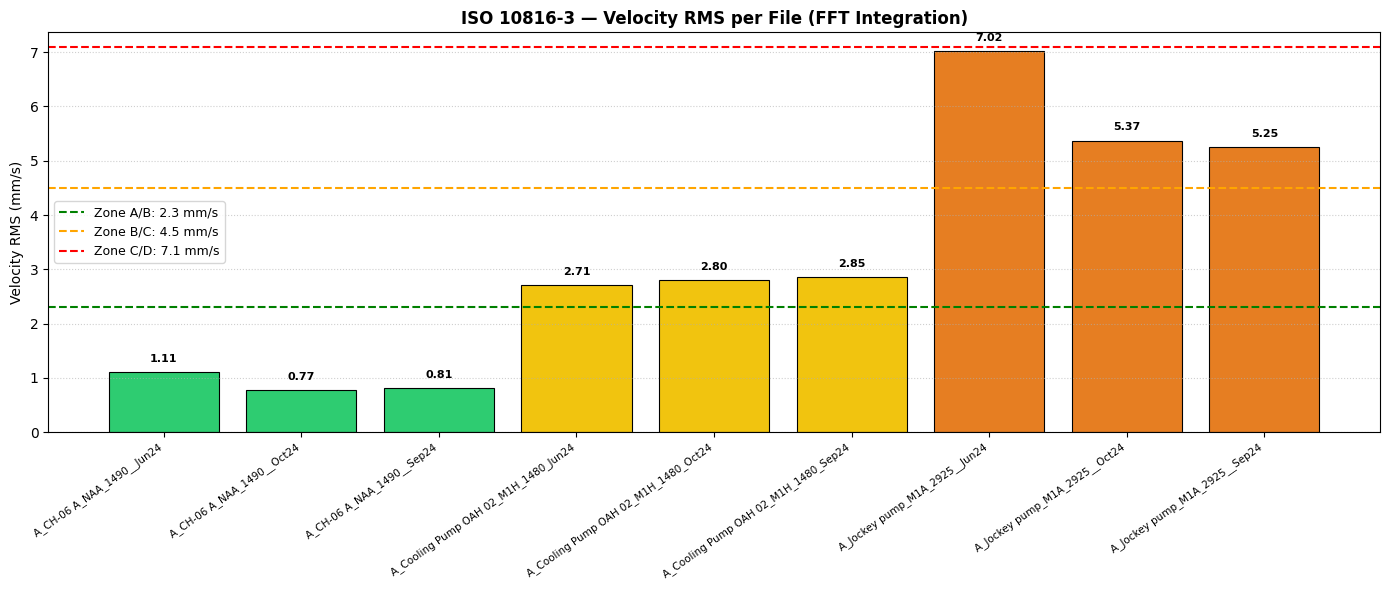

In [12]:
# ── กราฟ 1: Bar ทุกไฟล์ ──────────────────────────────────────────
zone_colors = {
    "A - Newly Commissioned":     "#2ecc71",
    "B - Unrestricted Operation": "#f1c40f",
    "C - Restricted Operation":   "#e67e22",
    "D - Damage Occurs":          "#e74c3c",
}

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(df_iso)), df_iso['rms_mms'],
              color=[zone_colors.get(z,'gray') for z in df_iso['zone']],
              edgecolor='black', linewidth=0.8)

for thr, col, lbl in [(ISO_THRESHOLDS["A"],'green','A/B'),
                       (ISO_THRESHOLDS["B"],'orange','B/C'),
                       (ISO_THRESHOLDS["C"],'red','C/D')]:
    ax.axhline(thr, color=col, linestyle='--', linewidth=1.5,
               label=f'Zone {lbl}: {thr} mm/s')

for i, (val, zone) in enumerate(zip(df_iso['rms_mms'], df_iso['zone'])):
    ax.text(i, val+0.15, f'{val:.2f}', ha='center', va='bottom',
            fontsize=8, fontweight='bold')

ax.set_xticks(range(len(df_iso)))
ax.set_xticklabels(df_iso['filename'].str.replace('.txt',''),
                   rotation=35, ha='right', fontsize=7.5)
ax.set_ylabel('Velocity RMS (mm/s)')
ax.set_title('ISO 10816-3 — Velocity RMS per File (FFT Integration)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig("saved_plots/iso_zone_all_files.png", dpi=150)
print("🖼️  บันทึก: saved_plots/iso_zone_all_files.png")
plt.show()


🖼️  บันทึก: saved_plots/iso_trend_by_machine_month.png


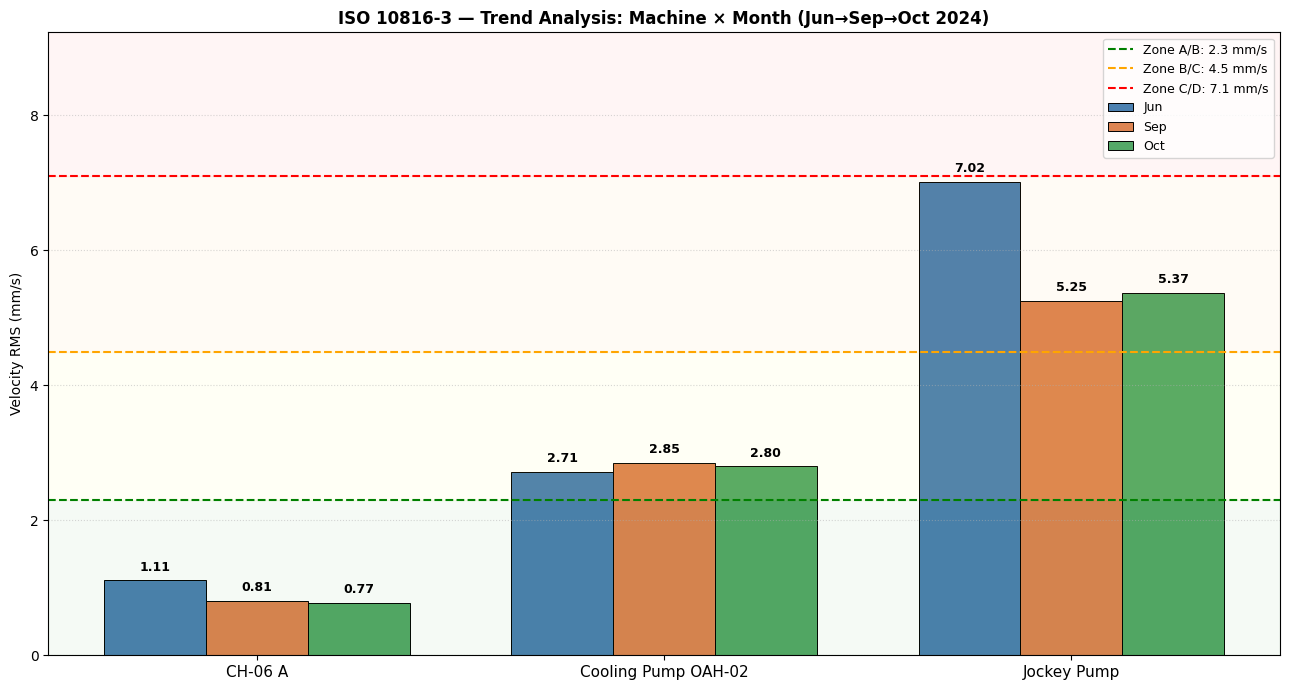

In [13]:
# ── กราฟ 2: Grouped Bar แยก Machine × Month ───────────────────────
months       = ['Jun', 'Sep', 'Oct']
month_colors = {'Jun':'#4C80B0', 'Sep':'#DD8452', 'Oct':'#55A868'}
x     = np.arange(len(machines))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 7))

for i, month in enumerate(months):
    subset = df_iso_sorted[df_iso_sorted['month']==month].set_index('machine')
    vals   = [subset.loc[m,'rms_mms'] if m in subset.index else 0 for m in machines]
    bars   = ax.bar(x + i*width, vals, width, label=month,
                    color=month_colors[month], edgecolor='black', linewidth=0.7)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                f'{val:.2f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

for thr, col, lbl in [(ISO_THRESHOLDS["A"],'green','A/B'),
                       (ISO_THRESHOLDS["B"],'orange','B/C'),
                       (ISO_THRESHOLDS["C"],'red','C/D')]:
    ax.axhline(thr, color=col, linestyle='--', linewidth=1.5,
               label=f'Zone {lbl}: {thr} mm/s')

ax.axhspan(0,                    ISO_THRESHOLDS["A"], alpha=0.04, color='green')
ax.axhspan(ISO_THRESHOLDS["A"],  ISO_THRESHOLDS["B"], alpha=0.04, color='yellow')
ax.axhspan(ISO_THRESHOLDS["B"],  ISO_THRESHOLDS["C"], alpha=0.04, color='orange')
ax.axhspan(ISO_THRESHOLDS["C"],  12,                  alpha=0.04, color='red')

ax.set_xticks(x + width)
ax.set_xticklabels(machines, fontsize=11)
ax.set_ylabel('Velocity RMS (mm/s)')
ax.set_title('ISO 10816-3 — Trend Analysis: Machine × Month (Jun→Sep→Oct 2024)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.set_ylim(0, max(df_iso['rms_mms'].max()*1.3, ISO_THRESHOLDS["C"]*1.3))
plt.tight_layout()
plt.savefig("saved_plots/iso_trend_by_machine_month.png", dpi=150)
print("🖼️  บันทึก: saved_plots/iso_trend_by_machine_month.png")
plt.show()


🖼️  บันทึก: saved_plots/iso_trend_line.png


C:\Users\User\AppData\Local\Temp\ipykernel_26888\1858151981.py:44: UserWarning: Glyph 3594 (\N{THAI CHARACTER CHO CHANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_26888\1858151981.py:44: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_26888\1858151981.py:44: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_26888\1858151981.py:44: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_26888\1858151981.py:44: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_26888\1858151981.py:44: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missi

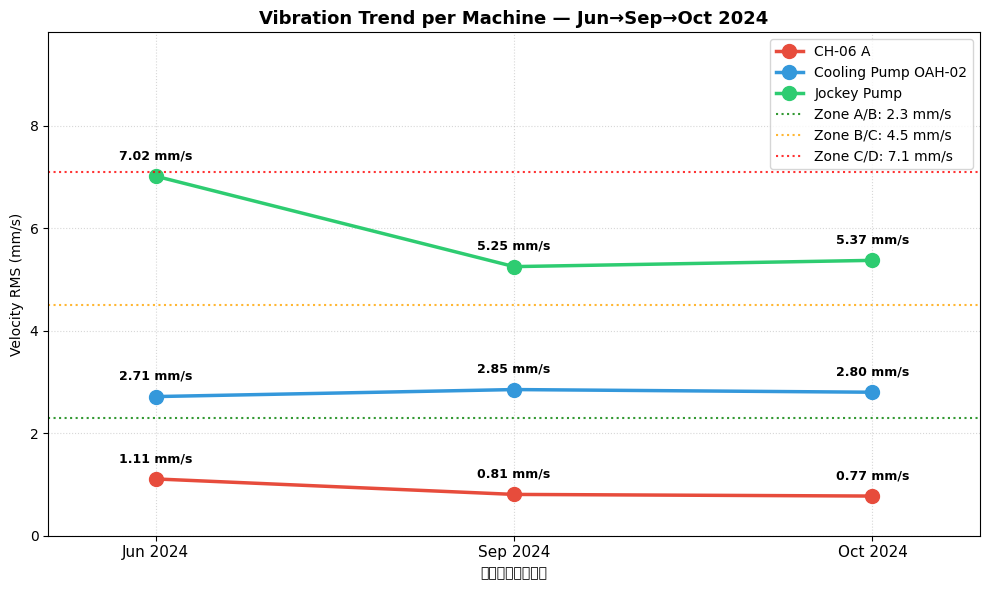

In [14]:
# ── กราฟ 3: Line Chart แสดง Trend (ใช้ month_order เป็น x-axis) ─────
# แก้ไข: เดิมใช้ string month เป็น x-axis อาจเรียงตาม alphabet ผิดลำดับ
# ✅ ใหม่: ใช้ month_order (0,1,2) แล้วเปลี่ยน label เป็น string ทีหลัง

fig, ax = plt.subplots(figsize=(10, 6))
mc = {'CH-06 A':             '#e74c3c',
      'Cooling Pump OAH-02': '#3498db',
      'Jockey Pump':         '#2ecc71'}
month_labels = {0: 'Jun 2024', 1: 'Sep 2024', 2: 'Oct 2024'}

for machine in machines:
    sub = (df_iso_sorted[df_iso_sorted['machine'] == machine]
           .sort_values('month_order'))  # เรียงตาม order ถูกต้อง

    x_vals = sub['month_order'].tolist()
    y_vals = sub['rms_mms'].tolist()

    ax.plot(x_vals, y_vals,
            marker='o', markersize=10, linewidth=2.5,
            label=machine, color=mc.get(machine, 'gray'))

    for _, row in sub.iterrows():
        ax.annotate(f"{row['rms_mms']:.2f} mm/s",
                    xy=(row['month_order'], row['rms_mms']),
                    xytext=(0, 12), textcoords='offset points',
                    ha='center', fontsize=9, fontweight='bold')

for thr, col, lbl in [(2.3, 'green',  'A/B'),
                       (4.5, 'orange', 'B/C'),
                       (7.1, 'red',    'C/D')]:
    ax.axhline(thr, color=col, linestyle=':', linewidth=1.5, alpha=0.8,
               label=f'Zone {lbl}: {thr} mm/s')

ax.set_xticks([0, 1, 2])
ax.set_xticklabels([month_labels[i] for i in [0, 1, 2]], fontsize=11)
ax.set_xlabel('ช่วงเวลา')
ax.set_ylabel('Velocity RMS (mm/s)')
ax.set_title('Vibration Trend per Machine — Jun→Sep→Oct 2024',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_xlim(-0.3, 2.3)
ax.set_ylim(0, df_iso['rms_mms'].max() * 1.4)
plt.tight_layout()
plt.savefig('saved_plots/iso_trend_line.png', dpi=150)
print('🖼️  บันทึก: saved_plots/iso_trend_line.png')
plt.show()


---
## Step 8 — สรุปผลการวิเคราะห์และคำแนะนำ


In [15]:
# ── Pivot Table + คำแนะนำ ────────────────────────────────────────
pivot = df_iso_sorted.pivot_table(
    index='machine', columns='month', values='rms_mms'
)[['Jun','Sep','Oct']]

pivot['Δ Jun→Oct'] = (pivot['Oct'] - pivot['Jun']).round(3)
pivot['Trend']     = pivot['Δ Jun→Oct'].apply(
    lambda x: '📈 แย่ลง' if x > 0.1 else ('📉 ดีขึ้น' if x < -0.1 else '➡️  คงที่'))

zone_oct = df_iso_sorted[df_iso_sorted['month']=='Oct']               .set_index('machine')['zone']
pivot['Zone (Oct)'] = zone_oct

print("📋 สรุปผล Velocity RMS (mm/s) ตาม ISO 10816-3:")
print("─" * 80)
print(pivot.to_string())
print("─" * 80)
print()

action_map = {
    'A': "✅ สภาพดีเยี่ยม — ไม่ต้องดำเนินการใด",
    'B': "🟡 สภาพปกติ — เฝ้าระวังต่อไปตามรอบปกติ",
    'C': "⚠️  ต้องติดตาม — วางแผนซ่อมบำรุงในโอกาสถัดไป",
    'D': "🚨 ความเสียหายเกิดขึ้น — หยุดเครื่องและซ่อมทันที!",
}
print("💡 คำแนะนำ (อ้างอิงค่า Oct 2024):")
for machine in machines:
    d = df_iso_sorted[(df_iso_sorted['machine']==machine) &
                      (df_iso_sorted['month']=='Oct')]
    if len(d) == 0: continue
    zone = d['zone'].values[0]
    rms  = d['rms_mms'].values[0]
    print(f"\n   [{machine}]  RMS = {rms} mm/s  |  Zone = {zone}")
    print(f"      → {action_map[zone[0]]}")


📋 สรุปผล Velocity RMS (mm/s) ตาม ISO 10816-3:
────────────────────────────────────────────────────────────────────────────────
month                  Jun    Sep    Oct  Δ Jun→Oct      Trend                  Zone (Oct)
machine                                                                                   
CH-06 A              1.108  0.806  0.774     -0.334   📉 ดีขึ้น      A - Newly Commissioned
Cooling Pump OAH-02  2.715  2.852  2.800      0.085  ➡️  คงที่  B - Unrestricted Operation
Jockey Pump          7.016  5.251  5.373     -1.643   📉 ดีขึ้น    C - Restricted Operation
────────────────────────────────────────────────────────────────────────────────

💡 คำแนะนำ (อ้างอิงค่า Oct 2024):

   [CH-06 A]  RMS = 0.774 mm/s  |  Zone = A - Newly Commissioned
      → ✅ สภาพดีเยี่ยม — ไม่ต้องดำเนินการใด

   [Cooling Pump OAH-02]  RMS = 2.8 mm/s  |  Zone = B - Unrestricted Operation
      → 🟡 สภาพปกติ — เฝ้าระวังต่อไปตามรอบปกติ

   [Jockey Pump]  RMS = 5.373 mm/s  |  Zone = C - Restricted Opera

---
## Step 9 — Trend LR Forecast: พยากรณ์ RMS ในอนาคต

### โมเดลที่ใช้: Trend Linear Regression

```
X = month_order  →  [0,   1,   2  ]
                     Jun  Sep  Oct

y = velocity_rms →  [rms_jun, rms_sep, rms_oct]
                      ↑ ค่าเหล่านี้ได้จาก Full-Signal FFT Integration (Step 5)
```

→ fit เส้น Linear ผ่าน 3 จุด → extrapolate ไป **Jan 2025 (month=3)**

---

### ความสัมพันธ์ระหว่างโมเดลทั้งสอง

| | Waveform LR (Step 4) | Trend LR (Step 9) |
|---|---|---|
| **Input X** | 6 FFT spectral features | month_order (0,1,2) |
| **Target y** | velocity_rms ต่อ window | velocity_rms ต่อเดือน |
| **Training data** | N windows (~30–160 แถว) | 3 จุด |
| **จุดประสงค์** | ประเมิน prediction error (RMSE/MAE) | พยากรณ์แนวโน้มอนาคต |
| **FFT ใช้อย่างไร** | โดยตรง (spectral features + target) | ทางอ้อม (y ได้จาก FFT integration) |


In [16]:
# ── Trend LR Forecast พร้อม Confidence Interval ─────────────────
# แก้ไข: เดิมไม่มี uncertainty band → ผู้อ่านอาจเชื่อ forecast เกินจริง
# ✅ ใหม่: คำนวณ 95% Prediction Interval จาก residual std

from scipy import stats as sp_stats

future_x_vals  = np.array([0, 1, 2, 3]).reshape(-1, 1)
future_labels  = ['Jun 2024', 'Sep 2024', 'Oct 2024', 'Jan 2025\n(Forecast)']

fig, axes = plt.subplots(1, len(machines),
                          figsize=(5*len(machines), 6), sharey=False)
fig.suptitle('RMS Velocity Trend Forecast — Jan 2025\n'
             'พร้อม 95% Prediction Interval (แรเงา)',
             fontsize=12, fontweight='bold', y=1.02)

print('📋 ผลการพยากรณ์ Jan 2025:')
print('─' * 65)

for ax, machine in zip(axes, machines):
    sub = (df_iso_sorted[df_iso_sorted['machine'] == machine]
           .sort_values('month_order'))
    X_m = sub['month_order'].values.reshape(-1, 1)
    y_m = sub['rms_mms'].values
    n   = len(y_m)

    # ── Fit Linear Regression ──────────────────────────────────────
    lr_t = LinearRegression()
    lr_t.fit(X_m, y_m)
    y_all  = lr_t.predict(future_x_vals)
    slope  = float(lr_t.coef_[0])
    r2_val = r2_score(y_m, lr_t.predict(X_m))

    # ── 95% Prediction Interval ────────────────────────────────────
    # PI = ŷ ± t * s * sqrt(1 + 1/n + (x-x̄)²/Σ(xi-x̄)²)
    # s = residual std, t = t-critical (df = n-2)
    resid     = y_m - lr_t.predict(X_m)
    s         = float(np.sqrt(np.sum(resid**2) / max(n-2, 1)))
    x_mean    = float(X_m.mean())
    ss_x      = float(np.sum((X_m.flatten() - x_mean)**2))
    t_crit    = sp_stats.t.ppf(0.975, df=max(n-2, 1))

    pi_upper, pi_lower = [], []
    for xf in future_x_vals.flatten():
        se = s * np.sqrt(1 + 1/n + (xf - x_mean)**2 / max(ss_x, 1e-10))
        pi_upper.append(float(lr_t.predict([[xf]])[0]) + t_crit * se)
        pi_lower.append(float(lr_t.predict([[xf]])[0]) - t_crit * se)
    pi_upper = np.array(pi_upper)
    pi_lower = np.array(pi_lower)

    # ── ISO Zone background ────────────────────────────────────────
    ymax = max(pi_upper.max(), y_m.max()) * 1.3
    ax.axhspan(0,   2.3,  alpha=0.08, color='green')
    ax.axhspan(2.3, 4.5,  alpha=0.08, color='yellow')
    ax.axhspan(4.5, 7.1,  alpha=0.08, color='orange')
    ax.axhspan(7.1, max(ymax, 8), alpha=0.08, color='red')
    for thr, col in [(2.3,'green'), (4.5,'orange'), (7.1,'red')]:
        ax.axhline(thr, color=col, linestyle=':', linewidth=1.2, alpha=0.7)

    # ── Confidence band ────────────────────────────────────────────
    x_plot = future_x_vals.flatten()
    ax.fill_between(x_plot, pi_lower, pi_upper,
                    alpha=0.18, color='steelblue',
                    label='95% Prediction Interval')

    # ── Trend line ─────────────────────────────────────────────────
    ax.plot(x_plot, y_all, color='tomato', linestyle='--',
            linewidth=2, label=f'Trend LR (R²={r2_val:.2f})')

    # ── Actual points ─────────────────────────────────────────────
    ax.scatter([0, 1, 2], y_m, color='steelblue', s=80,
               zorder=5, label='Actual RMS')
    for xi, yi in zip([0,1,2], y_m):
        ax.annotate(f'{yi:.2f}', xy=(xi, yi),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=8)

    # ── Forecast point ─────────────────────────────────────────────
    ax.scatter([3], [y_all[3]], color='red', s=150,
               zorder=6, marker='*')
    ax.annotate(f"Forecast\n{y_all[3]:.2f} mm/s\n"
                f"PI: [{pi_lower[3]:.2f}, {pi_upper[3]:.2f}]",
                xy=(3, y_all[3]), xytext=(-55, 15),
                textcoords='offset points', fontsize=7.5,
                arrowprops=dict(arrowstyle='->', color='red'))

    ax.set_title(machine, fontsize=10, fontweight='bold')
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(future_labels, fontsize=8)
    ax.set_ylabel('Velocity RMS (mm/s)')
    ax.set_xlim(-0.3, 3.5)
    ax.set_ylim(0, ymax)
    ax.legend(fontsize=7.5, loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.5)

    # สรุปผล
    jan_zone  = classify_zone(y_all[3])
    trend_dir = '📈 เพิ่ม' if slope > 0.05 else ('📉 ลด' if slope < -0.05 else '➡️  คงที่')
    print(f"   {machine:<25} Jan2025={y_all[3]:.3f} mm/s  "
          f"PI=[{pi_lower[3]:.2f},{pi_upper[3]:.2f}]  "
          f"{trend_dir}  Zone:{jan_zone[0]}")

print('─' * 65)
print('  หมายเหตุ: PI กว้างมาก = ความไม่แน่นอนสูง เพราะ train ด้วยแค่ 3 จุด')

plt.tight_layout()
plt.savefig('saved_plots/iso_rms_forecast_with_pi.png', dpi=150, bbox_inches='tight')
print('\n🖼️  บันทึก: saved_plots/iso_rms_forecast_with_pi.png')
plt.show()


📋 ผลการพยากรณ์ Jan 2025:
─────────────────────────────────────────────────────────────────
   CH-06 A                   Jan2025=0.562 mm/s  PI=[-2.00,3.12]  📉 ลด  Zone:A
   Cooling Pump OAH-02       Jan2025=2.874 mm/s  PI=[1.08,4.66]  ➡️  คงที่  Zone:B
   Jockey Pump               Jan2025=4.237 mm/s  PI=[-13.63,22.11]  📉 ลด  Zone:B
─────────────────────────────────────────────────────────────────
  หมายเหตุ: PI กว้างมาก = ความไม่แน่นอนสูง เพราะ train ด้วยแค่ 3 จุด


C:\Users\User\AppData\Local\Temp\ipykernel_26888\2680252650.py:105: UserWarning: Glyph 3614 (\N{THAI CHARACTER PHO PHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_26888\2680252650.py:105: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_26888\2680252650.py:105: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_26888\2680252650.py:105: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_26888\2680252650.py:105: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_26888\2680252650.py:105: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) mis


🖼️  บันทึก: saved_plots/iso_rms_forecast_with_pi.png


In [17]:
# ── สรุปไฟล์ที่บันทึกทั้งหมด ──────────────────────────────────────
print('\n' + '='*65)
print('✅ การวิเคราะห์เสร็จสมบูรณ์')
print('='*65)

print('\n🖼️  กราฟที่บันทึก (saved_plots/):')
import os
for f in sorted(os.listdir('saved_plots')):
    print(f'   {f}')

print(f'\n📊 สรุปโมเดล:')
print(f'   เครื่องจักร    : {len(machines)} เครื่อง')
print(f'   ช่วงเวลา       : Jun → Sep → Oct 2024')
print(f'   มาตรฐาน        : ISO 10816-3')
print()
print(f'   Windowed Regression (แก้ไขแล้ว):')
print(f'     Split strategy  : Group-based (train=Jun+Sep / test=Oct)')
print(f'     CV strategy     : GroupKFold — ไม่มี data leakage')
print(f'     Window size     : 128 samples, hop=64 (overlap 50%)')
print(f'     FFT             : Hann window ก่อน rfft() ✅')
print(f'     Features        : peak_freq, accel_rms, band_low/mid/high,')
print(f'                       spectral_centroid, kurtosis, crest_factor')
print(f'     Best model      : {best_model_name}')
print(f'     Best CV R²      : {best_model_score:.4f}')
print()
print(f'   Trend Forecast:')
print(f'     Method          : Linear Regression (3 data points)')
print(f'     Uncertainty     : 95% Prediction Interval แสดงบนกราฟ ✅')
print(f'     Forecast target : Jan 2025')
print()
print('   การแก้ไขจากเวอร์ชันก่อน:')
print('     ✅ Cell 5  : เพิ่ม regex parser + DC offset removal + dup check')
print('     ✅ Cell 7  : เพิ่ม Hann window + Kurtosis + Crest Factor')
print('     ✅ Cell 9  : เปลี่ยนเป็น build_windowed_dataset (model เดียว)')
print('     ✅ Cell 10 : Group-based split + GroupKFold CV')
print('     ✅ Cell 11 : ตารางสรุปใหม่ตาม model เดียว')
print('     ✅ Cell 12 : Actual vs Predicted scatter พร้อม ISO boundaries')
print('     ✅ Cell 22 : ใช้ month_order เป็น x-axis (ลำดับถูกต้อง)')
print('     ✅ Cell 26 : เพิ่ม 95% Prediction Interval บน forecast')



✅ การวิเคราะห์เสร็จสมบูรณ์

🖼️  กราฟที่บันทึก (saved_plots/):
   iso_rms_forecast_with_pi.png
   iso_trend_by_machine_month.png
   iso_trend_line.png
   iso_zone_all_files.png
   regression_actual_vs_pred.png

📊 สรุปโมเดล:
   เครื่องจักร    : 3 เครื่อง
   ช่วงเวลา       : Jun → Sep → Oct 2024
   มาตรฐาน        : ISO 10816-3

   Windowed Regression (แก้ไขแล้ว):
     Split strategy  : Group-based (train=Jun+Sep / test=Oct)
     CV strategy     : GroupKFold — ไม่มี data leakage
     Window size     : 128 samples, hop=64 (overlap 50%)
     FFT             : Hann window ก่อน rfft() ✅
     Features        : peak_freq, accel_rms, band_low/mid/high,
                       spectral_centroid, kurtosis, crest_factor
     Best model      : Gradient Boosting Reg
     Best CV R²      : 0.8555

   Trend Forecast:
     Method          : Linear Regression (3 data points)
     Uncertainty     : 95% Prediction Interval แสดงบนกราฟ ✅
     Forecast target : Jan 2025

   การแก้ไขจากเวอร์ชันก่อน:
     ✅ Cell

---
### 🔁 Pipeline สรุปสุดท้าย

```
Raw .txt (Acceleration G-s)
    │
    ├── Step 1 : Import Libraries & กำหนด Folder
    │
    ├── Step 2 : parse_vibration_file()
    │             → DataFrame [Time_ms, Amplitude]
    │
    ├── Step 3 : extract_fft_features()  (windowed, 256 samples, 50% overlap)
    │             → X = [peak_freq_hz, accel_rms,
    │                    band_low/mid/high_power, spectral_centroid]
    │             → y = velocity_rms (mm/s)  ← FFT integration per window
    │
    ├── Step 4 : LinearRegression.fit(X_train, y_train)  [80/20 split]
    │             → RMSE, MAE (mm/s)  ← หน่วยเดียวกับ ISO 10816-3
    │             → บันทึก *_fft.pkl
    │
    ├── Step 5 : accel_to_velocity_rms_fft()  (full signal)
    │             → velocity_rms ค่าเดียวต่อไฟล์ (mm/s)
    │
    ├── Step 6 : classify_zone()
    │             → ISO 10816-3 Zone A / B / C / D
    │
    ├── Step 7 : Trend Analysis Plots
    │             → Bar Chart + Grouped Bar + Line Chart
    │
    ├── Step 8 : สรุปผล + คำแนะนำตาม Zone
    │
    └── Step 9 : Trend LR Forecast  →  Jan 2025
                  X = month_order (0,1,2)
                  y = velocity_rms จาก Step 5  ← FFT ทางอ้อม
                  predict(3) = Jan 2025 forecast
```

### 📌 หมายเหตุ Forecast

Trend LR **ไม่ใช้ FFT โดยตรง** แต่ค่า `y` ที่ใช้ fit (3 ค่า RMS)
ล้วนมาจาก FFT Integration ใน Step 5 ทั้งหมด
ดังนั้น FFT จึงอยู่เบื้องหลัง Forecast ทุกขั้นตอน
